In [6]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from scipy.stats import entropy
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# Try UMAP (optional)
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("⚠️ UMAP not available. Will use t-SNE only.")

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully")
print(f"  UMAP Available: {UMAP_AVAILABLE}")

⚠️ UMAP not available. Will use t-SNE only.
✓ Libraries imported successfully
  UMAP Available: False


## 1. Load Dataset

In [7]:
# Load cleaned dataset
df = pd.read_csv('../data/processed/cleaned_dataset.csv')
df['student_id'] = df['source_file'].str.extract(r'-(\d+)\.csv$')[0]

print(f"Dataset loaded: {len(df)} records")
print(f"Unique students: {df['student_id'].nunique()}")
df.head(3)

Dataset loaded: 955 records
Unique students: 88


,source_file,Image URL,Description,Country,Country_Standardized,Time of Day,Time_of_Day_Standardized,preference,student_id,Activity_Type,Weather_Type,Mood_Category
0,2936035-1161937.csv,https://commons.wikimedia.org/wiki/File:Dom_of...,a clear image of the dome of the rock in jerus...,palestine,Palestine,afternoon,Afternoon,1,1161937,Nature,Sunny,Relaxing
1,2936035-1161937.csv,https://upload.wikimedia.org/wikipedia/commons...,a clear image of the ibrahimi mosque (cave of ...,palestine,Palestine,morning,Morning,1,1161937,Nature,Sunny,Relaxing
2,2936035-1161937.csv,https://upload.wikimedia.org/wikipedia/commons...,a clear image of the ancient ruins in sebastia...,palestine,Palestine,afternoon,Afternoon,1,1161937,History,Sunny,Relaxing


## 2. Create Student-Level Features

In [8]:
print("=" * 80)
print("STUDENT-LEVEL FEATURE ENGINEERING")
print("=" * 80)

# Create student profile features
student_features = []

for student_id in df['student_id'].unique():
    student_df = df[df['student_id'] == student_id]
    
    # Basic counts
    n_places = len(student_df)
    
    # Category diversity (unique counts)
    n_activities = student_df['Activity_Type'].nunique()
    n_weather = student_df['Weather_Type'].nunique()
    n_moods = student_df['Mood_Category'].nunique()
    n_countries = student_df['Country_Standardized'].nunique()
    
    # Category entropy (preference diversity)
    def calc_entropy(series):
        counts = series.value_counts(normalize=True)
        return entropy(counts)
    
    activity_entropy = calc_entropy(student_df['Activity_Type'])
    weather_entropy = calc_entropy(student_df['Weather_Type'])
    mood_entropy = calc_entropy(student_df['Mood_Category'])
    
    # Most common preferences
    primary_activity = student_df['Activity_Type'].mode()[0] if len(student_df['Activity_Type'].mode()) > 0 else 'Unknown'
    primary_weather = student_df['Weather_Type'].mode()[0] if len(student_df['Weather_Type'].mode()) > 0 else 'Unknown'
    primary_mood = student_df['Mood_Category'].mode()[0] if len(student_df['Mood_Category'].mode()) > 0 else 'Unknown'
    
    # Description statistics
    avg_desc_length = student_df['Description'].fillna('').astype(str).apply(len).mean()
    
    student_features.append({
        'student_id': student_id,
        'n_places': n_places,
        'n_activities': n_activities,
        'n_weather': n_weather,
        'n_moods': n_moods,
        'n_countries': n_countries,
        'activity_entropy': activity_entropy,
        'weather_entropy': weather_entropy,
        'mood_entropy': mood_entropy,
        'primary_activity': primary_activity,
        'primary_weather': primary_weather,
        'primary_mood': primary_mood,
        'avg_desc_length': avg_desc_length
    })

student_df = pd.DataFrame(student_features).fillna(0)

print(f"\n✓ Created features for {len(student_df)} students")
print(f"\nFeature columns: {list(student_df.columns)}")
print(f"\nSample student profiles:")
student_df.head()

STUDENT-LEVEL FEATURE ENGINEERING

✓ Created features for 89 students

Feature columns: ['student_id', 'n_places', 'n_activities', 'n_weather', 'n_moods', 'n_countries', 'activity_entropy', 'weather_entropy', 'mood_entropy', 'primary_activity', 'primary_weather', 'primary_mood', 'avg_desc_length']

Sample student profiles:


,student_id,n_places,n_activities,n_weather,n_moods,n_countries,activity_entropy,weather_entropy,mood_entropy,primary_activity,primary_weather,primary_mood,avg_desc_length
0,1161937,10,3,1,3,6,0.639032,0.000000,0.801819,Nature,Sunny,Relaxing,148.7
1,1181804,10,4,3,1,10,1.168282,0.801819,0.000000,Nature,Sunny,Relaxing,58.3
2,1190855,10,3,3,1,10,0.897946,0.639032,0.000000,Nature,Sunny,Relaxing,86.5
3,1200242,10,2,2,3,10,0.325083,0.325083,0.639032,Nature,Sunny,Relaxing,206.2
4,1200431,10,3,2,1,10,0.943348,0.500402,0.000000,Leisure/Other,Sunny,Relaxing,56.7


## 3. Preference Diversity Analysis

PREFERENCE DIVERSITY ANALYSIS

📊 Diversity Statistics:

Activity Diversity:
count    89.000000
mean      2.853933
std       0.911424
min       0.000000
25%       2.000000
50%       3.000000
75%       3.000000
max       4.000000
Name: n_activities, dtype: float64

Activity Entropy (higher = more diverse):
count    89.000000
mean      0.770560
std       0.361086
min       0.000000
25%       0.610864
50%       0.801819
75%       1.029653
max       1.368922
Name: activity_entropy, dtype: float64

Country Diversity:
count    89.000000
mean      8.865169
std       1.610978
min       0.000000
25%       8.000000
50%       9.000000
75%      10.000000
max      10.000000
Name: n_countries, dtype: float64


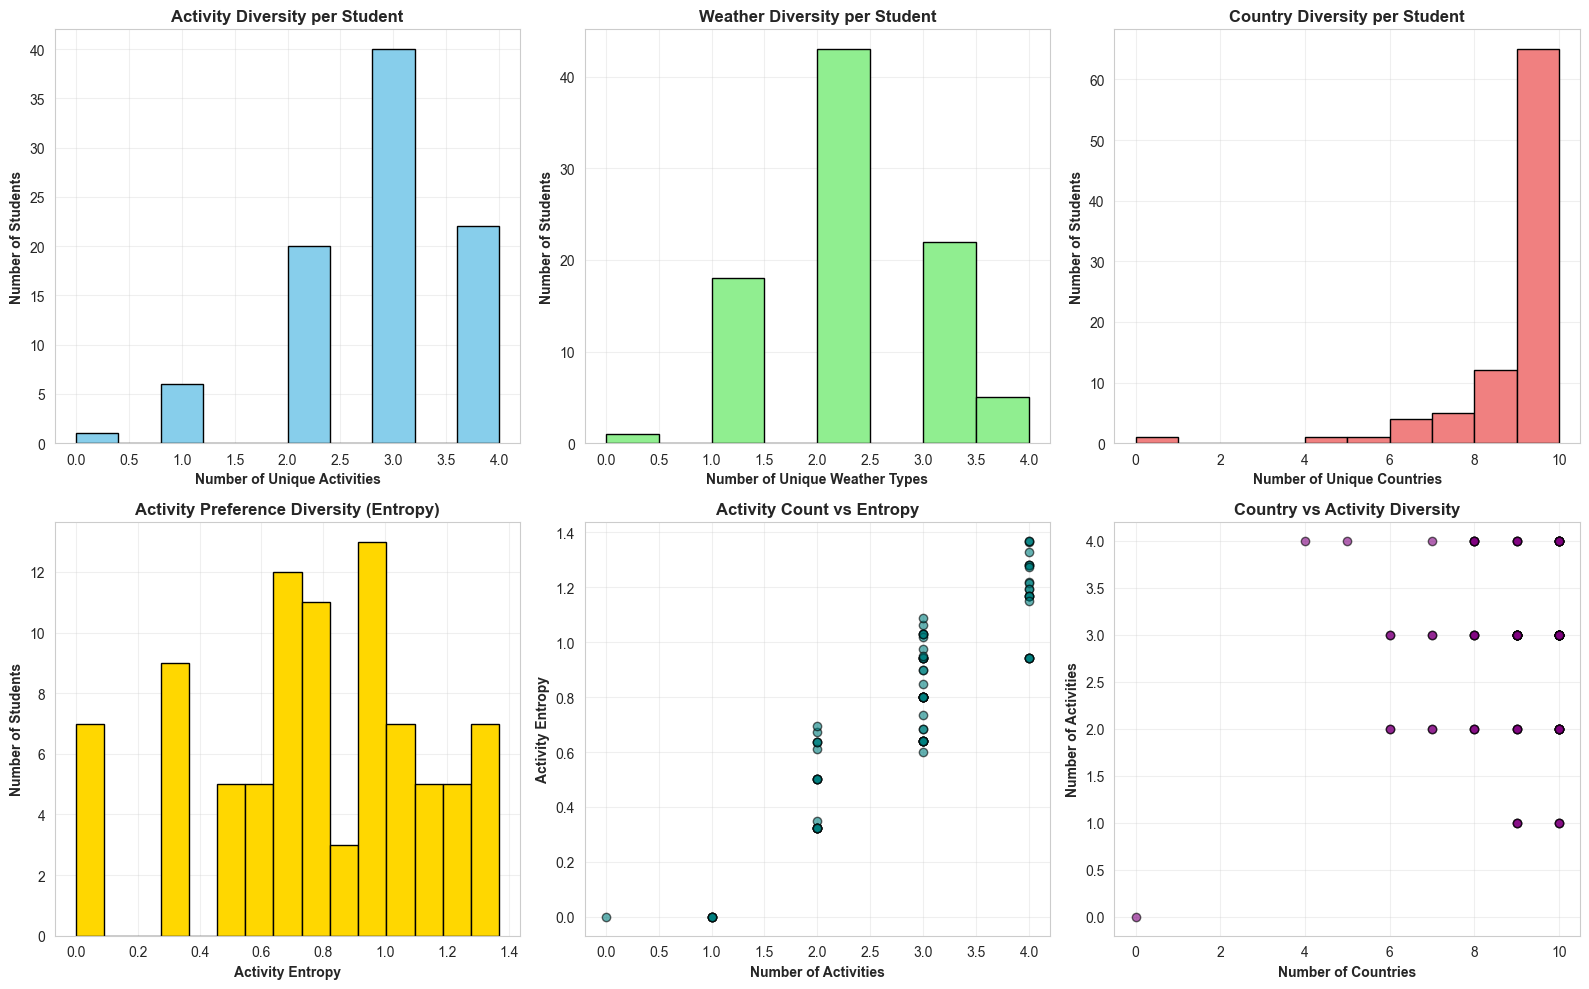


✓ Saved: results/figures/eda_visuals/preference_diversity.png


In [9]:
print("=" * 80)
print("PREFERENCE DIVERSITY ANALYSIS")
print("=" * 80)

print(f"\n📊 Diversity Statistics:")
print(f"\nActivity Diversity:")
print(student_df['n_activities'].describe())

print(f"\nActivity Entropy (higher = more diverse):")
print(student_df['activity_entropy'].describe())

print(f"\nCountry Diversity:")
print(student_df['n_countries'].describe())

# Visualize diversity
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Activity diversity
ax = axes[0, 0]
student_df['n_activities'].hist(bins=10, edgecolor='black', color='skyblue', ax=ax)
ax.set_xlabel('Number of Unique Activities', fontweight='bold')
ax.set_ylabel('Number of Students', fontweight='bold')
ax.set_title('Activity Diversity per Student', fontweight='bold')
ax.grid(alpha=0.3)

# Weather diversity
ax = axes[0, 1]
student_df['n_weather'].hist(bins=8, edgecolor='black', color='lightgreen', ax=ax)
ax.set_xlabel('Number of Unique Weather Types', fontweight='bold')
ax.set_ylabel('Number of Students', fontweight='bold')
ax.set_title('Weather Diversity per Student', fontweight='bold')
ax.grid(alpha=0.3)

# Country diversity
ax = axes[0, 2]
student_df['n_countries'].hist(bins=10, edgecolor='black', color='lightcoral', ax=ax)
ax.set_xlabel('Number of Unique Countries', fontweight='bold')
ax.set_ylabel('Number of Students', fontweight='bold')
ax.set_title('Country Diversity per Student', fontweight='bold')
ax.grid(alpha=0.3)

# Activity entropy
ax = axes[1, 0]
student_df['activity_entropy'].hist(bins=15, edgecolor='black', color='gold', ax=ax)
ax.set_xlabel('Activity Entropy', fontweight='bold')
ax.set_ylabel('Number of Students', fontweight='bold')
ax.set_title('Activity Preference Diversity (Entropy)', fontweight='bold')
ax.grid(alpha=0.3)

# Scatter: activity diversity vs entropy
ax = axes[1, 1]
ax.scatter(student_df['n_activities'], student_df['activity_entropy'], 
          alpha=0.6, edgecolor='black', c='teal')
ax.set_xlabel('Number of Activities', fontweight='bold')
ax.set_ylabel('Activity Entropy', fontweight='bold')
ax.set_title('Activity Count vs Entropy', fontweight='bold')
ax.grid(alpha=0.3)

# Scatter: country diversity vs activity diversity
ax = axes[1, 2]
ax.scatter(student_df['n_countries'], student_df['n_activities'], 
          alpha=0.6, edgecolor='black', c='purple')
ax.set_xlabel('Number of Countries', fontweight='bold')
ax.set_ylabel('Number of Activities', fontweight='bold')
ax.set_title('Country vs Activity Diversity', fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/eda_visuals/preference_diversity.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: results/figures/eda_visuals/preference_diversity.png")

## 4. Student Clustering

STUDENT CLUSTERING

Feature matrix shape: (89, 8)


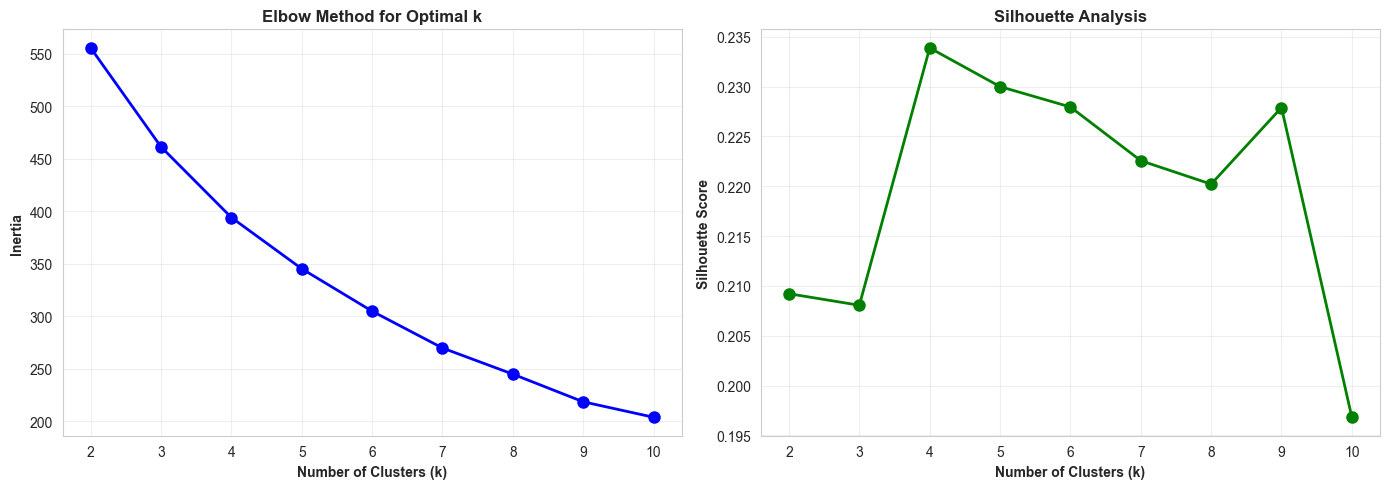


📊 Clustering Results:
  Best silhouette score at k=4: 0.234
  Using k=5 for interpretability

✓ Assigned 89 students to 5 clusters

Cluster sizes:
cluster
0    31
1    14
2     1
3    21
4    22
Name: count, dtype: int64


In [10]:
print("=" * 80)
print("STUDENT CLUSTERING")
print("=" * 80)

# Prepare features for clustering
feature_cols = ['n_activities', 'n_weather', 'n_moods', 'n_countries',
                'activity_entropy', 'weather_entropy', 'mood_entropy', 'avg_desc_length']

X = student_df[feature_cols].values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nFeature matrix shape: {X_scaled.shape}")

# K-Means clustering with different k values
inertias = []
silhouettes = []
k_range = range(2, 11)

from sklearn.metrics import silhouette_score

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Visualize elbow method
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
ax = axes[0]
ax.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Number of Clusters (k)', fontweight='bold')
ax.set_ylabel('Inertia', fontweight='bold')
ax.set_title('Elbow Method for Optimal k', fontweight='bold')
ax.grid(alpha=0.3)

# Silhouette scores
ax = axes[1]
ax.plot(k_range, silhouettes, 'go-', linewidth=2, markersize=8)
ax.set_xlabel('Number of Clusters (k)', fontweight='bold')
ax.set_ylabel('Silhouette Score', fontweight='bold')
ax.set_title('Silhouette Analysis', fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/eda_visuals/clustering_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Choose optimal k (e.g., k=5 or k=6)
optimal_k = 5
best_silhouette_idx = np.argmax(silhouettes)
suggested_k = list(k_range)[best_silhouette_idx]

print(f"\n📊 Clustering Results:")
print(f"  Best silhouette score at k={suggested_k}: {max(silhouettes):.3f}")
print(f"  Using k={optimal_k} for interpretability")

# Final clustering
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
student_df['cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"\n✓ Assigned {len(student_df)} students to {optimal_k} clusters")
print(f"\nCluster sizes:")
print(student_df['cluster'].value_counts().sort_index())

## 5. Dimensionality Reduction (t-SNE)

In [11]:
print("=" * 80)
print("DIMENSIONALITY REDUCTION")
print("=" * 80)

# PCA first (for initialization)
print("\n⏳ Running PCA...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"  Explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# t-SNE
print("\n⏳ Running t-SNE (this may take a moment)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(X_scaled)-1))
X_tsne = tsne.fit_transform(X_scaled)
print("  ✓ t-SNE complete")

# UMAP (if available)
if UMAP_AVAILABLE:
    print("\n⏳ Running UMAP...")
    reducer = umap.UMAP(n_components=2, random_state=42)
    X_umap = reducer.fit_transform(X_scaled)
    print("  ✓ UMAP complete")

# Add to dataframe
student_df['pca_1'] = X_pca[:, 0]
student_df['pca_2'] = X_pca[:, 1]
student_df['tsne_1'] = X_tsne[:, 0]
student_df['tsne_2'] = X_tsne[:, 1]

if UMAP_AVAILABLE:
    student_df['umap_1'] = X_umap[:, 0]
    student_df['umap_2'] = X_umap[:, 1]

print("\n✓ Dimensionality reduction complete")

DIMENSIONALITY REDUCTION

⏳ Running PCA...
  Explained variance: 0.578

⏳ Running t-SNE (this may take a moment)...
  ✓ t-SNE complete

✓ Dimensionality reduction complete


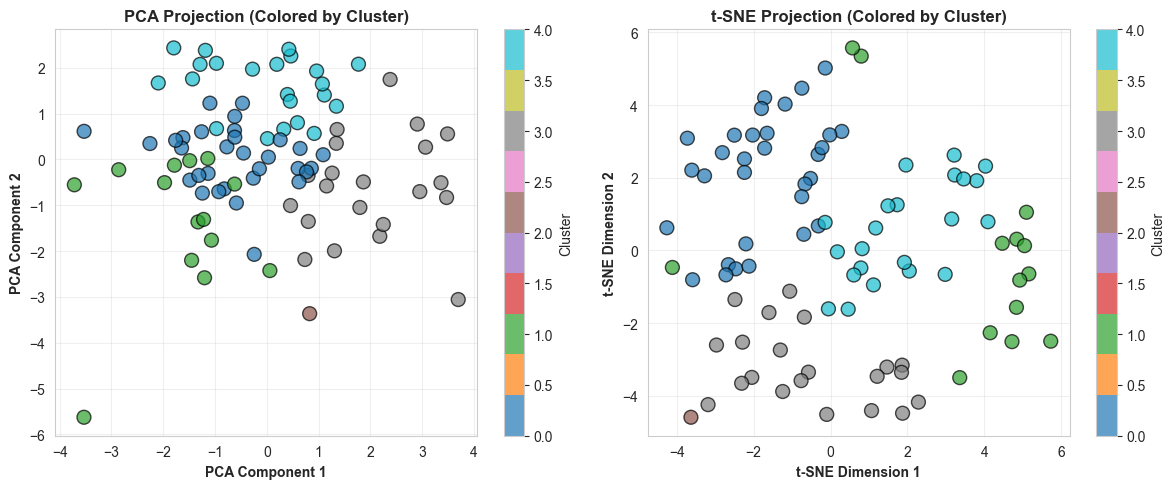

✓ Saved: results/figures/eda_visuals/student_clustering_visualization.png


In [12]:
# Visualize dimensionality reduction
n_plots = 3 if UMAP_AVAILABLE else 2
fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 5))

if n_plots == 2:
    axes = [axes[0], axes[1]]

# PCA
ax = axes[0]
scatter = ax.scatter(student_df['pca_1'], student_df['pca_2'], 
                     c=student_df['cluster'], cmap='tab10',
                     s=100, alpha=0.7, edgecolor='black', linewidth=1)
ax.set_xlabel('PCA Component 1', fontweight='bold')
ax.set_ylabel('PCA Component 2', fontweight='bold')
ax.set_title('PCA Projection (Colored by Cluster)', fontweight='bold')
ax.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Cluster')

# t-SNE
ax = axes[1]
scatter = ax.scatter(student_df['tsne_1'], student_df['tsne_2'], 
                     c=student_df['cluster'], cmap='tab10',
                     s=100, alpha=0.7, edgecolor='black', linewidth=1)
ax.set_xlabel('t-SNE Dimension 1', fontweight='bold')
ax.set_ylabel('t-SNE Dimension 2', fontweight='bold')
ax.set_title('t-SNE Projection (Colored by Cluster)', fontweight='bold')
ax.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Cluster')

# UMAP (if available)
if UMAP_AVAILABLE:
    ax = axes[2]
    scatter = ax.scatter(student_df['umap_1'], student_df['umap_2'], 
                         c=student_df['cluster'], cmap='tab10',
                         s=100, alpha=0.7, edgecolor='black', linewidth=1)
    ax.set_xlabel('UMAP Dimension 1', fontweight='bold')
    ax.set_ylabel('UMAP Dimension 2', fontweight='bold')
    ax.set_title('UMAP Projection (Colored by Cluster)', fontweight='bold')
    ax.grid(alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='Cluster')

plt.tight_layout()
plt.savefig('../results/figures/eda_visuals/student_clustering_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: results/figures/eda_visuals/student_clustering_visualization.png")

## 6. Identify Traveler Archetypes

In [13]:
print("=" * 80)
print("TRAVELER ARCHETYPES")
print("=" * 80)

# Analyze each cluster
archetypes = {}

for cluster_id in range(optimal_k):
    cluster_students = student_df[student_df['cluster'] == cluster_id]
    
    print(f"\n{'=' * 60}")
    print(f"CLUSTER {cluster_id} ({len(cluster_students)} students)")
    print(f"{'=' * 60}")
    
    # Statistical profile
    print(f"\n📊 Profile Statistics:")
    print(f"  Activity diversity: {cluster_students['n_activities'].mean():.2f} (±{cluster_students['n_activities'].std():.2f})")
    print(f"  Country diversity: {cluster_students['n_countries'].mean():.2f} (±{cluster_students['n_countries'].std():.2f})")
    print(f"  Activity entropy: {cluster_students['activity_entropy'].mean():.3f}")
    
    # Most common preferences
    print(f"\n🎯 Common Preferences:")
    print(f"  Primary activity: {cluster_students['primary_activity'].mode()[0] if len(cluster_students) > 0 else 'N/A'}")
    print(f"  Primary weather: {cluster_students['primary_weather'].mode()[0] if len(cluster_students) > 0 else 'N/A'}")
    print(f"  Primary mood: {cluster_students['primary_mood'].mode()[0] if len(cluster_students) > 0 else 'N/A'}")
    
    # Define archetype
    avg_activity_div = cluster_students['n_activities'].mean()
    avg_country_div = cluster_students['n_countries'].mean()
    primary_act = cluster_students['primary_activity'].mode()[0] if len(cluster_students) > 0 else 'Unknown'
    
    # Heuristic archetype naming
    if avg_activity_div >= 6 and avg_country_div >= 6:
        archetype_name = "🌍 Global Explorer"
        description = "Diverse interests, visits many countries and activities"
    elif avg_activity_div <= 3:
        archetype_name = f"🎯 Focused Traveler ({primary_act})"
        description = f"Concentrated preferences around {primary_act}"
    elif 'Sightseeing' in primary_act:
        archetype_name = "🏛️ Cultural Enthusiast"
        description = "Prefers sightseeing and cultural experiences"
    elif 'Beach' in primary_act or 'Water' in primary_act:
        archetype_name = "🏖️ Beach Lover"
        description = "Prefers water activities and beach destinations"
    elif 'Hiking' in primary_act or 'Nature' in primary_act:
        archetype_name = "🥾 Nature Adventurer"
        description = "Prefers outdoor and nature activities"
    else:
        archetype_name = f"🧳 Balanced Traveler"
        description = "Moderate diversity across activities"
    
    archetypes[cluster_id] = {
        'name': archetype_name,
        'description': description,
        'size': len(cluster_students),
        'avg_activity_diversity': float(avg_activity_div),
        'avg_country_diversity': float(avg_country_div),
        'primary_activity': primary_act
    }
    
    print(f"\n🏷️ Archetype: {archetype_name}")
    print(f"   {description}")

# Add archetype names to dataframe
student_df['archetype'] = student_df['cluster'].map(lambda x: archetypes[x]['name'])

print(f"\n\n{'=' * 80}")
print("ARCHETYPE SUMMARY")
print("=" * 80)
for cluster_id, info in archetypes.items():
    print(f"\nCluster {cluster_id}: {info['name']}")
    print(f"  Size: {info['size']} students")
    print(f"  {info['description']}")

TRAVELER ARCHETYPES

CLUSTER 0 (31 students)

📊 Profile Statistics:
  Activity diversity: 3.29 (±0.53)
  Country diversity: 9.35 (±0.91)
  Activity entropy: 0.920

🎯 Common Preferences:
  Primary activity: Nature
  Primary weather: Sunny
  Primary mood: Relaxing

🏷️ Archetype: 🥾 Nature Adventurer
   Prefers outdoor and nature activities

CLUSTER 1 (14 students)

📊 Profile Statistics:
  Activity diversity: 2.43 (±1.09)
  Country diversity: 6.57 (±2.44)
  Activity entropy: 0.608

🎯 Common Preferences:
  Primary activity: Nature
  Primary weather: Sunny
  Primary mood: Relaxing

🏷️ Archetype: 🎯 Focused Traveler (Nature)
   Concentrated preferences around Nature

CLUSTER 2 (1 students)

📊 Profile Statistics:
  Activity diversity: 2.00 (±nan)
  Country diversity: 6.00 (±nan)
  Activity entropy: 0.693

🎯 Common Preferences:
  Primary activity: History
  Primary weather: Sunny
  Primary mood: Relaxing

🏷️ Archetype: 🎯 Focused Traveler (History)
   Concentrated preferences around History

CLUS

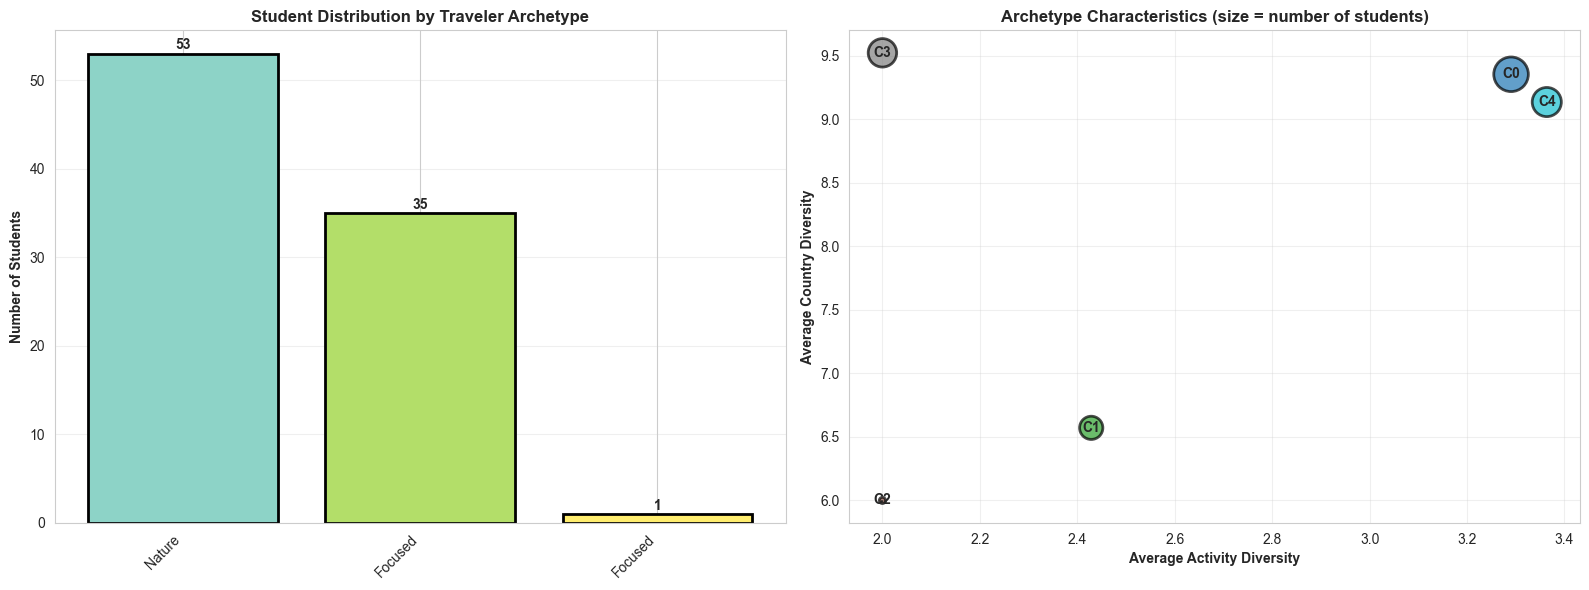


✓ Saved: results/figures/eda_visuals/traveler_archetypes.png


In [14]:
# Visualize archetypes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Archetype distribution
ax = axes[0]
archetype_counts = student_df['archetype'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(archetype_counts)))
ax.bar(range(len(archetype_counts)), archetype_counts.values, 
       color=colors, edgecolor='black', linewidth=2)
ax.set_xticks(range(len(archetype_counts)))
ax.set_xticklabels([name.split()[1] if len(name.split()) > 1 else name for name in archetype_counts.index], 
                   rotation=45, ha='right')
ax.set_ylabel('Number of Students', fontweight='bold')
ax.set_title('Student Distribution by Traveler Archetype', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3, axis='y')

for i, v in enumerate(archetype_counts.values):
    ax.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Archetype characteristics
ax = axes[1]
cluster_ids = list(archetypes.keys())
activity_divs = [archetypes[c]['avg_activity_diversity'] for c in cluster_ids]
country_divs = [archetypes[c]['avg_country_diversity'] for c in cluster_ids]
sizes = [archetypes[c]['size'] for c in cluster_ids]

scatter = ax.scatter(activity_divs, country_divs, s=[s*20 for s in sizes], 
                     c=cluster_ids, cmap='tab10', alpha=0.7, edgecolor='black', linewidth=2)
ax.set_xlabel('Average Activity Diversity', fontweight='bold')
ax.set_ylabel('Average Country Diversity', fontweight='bold')
ax.set_title('Archetype Characteristics (size = number of students)', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3)

# Add labels
for i, cluster_id in enumerate(cluster_ids):
    ax.annotate(f"C{cluster_id}", (activity_divs[i], country_divs[i]), 
               fontweight='bold', ha='center', va='center')

plt.tight_layout()
plt.savefig('../results/figures/eda_visuals/traveler_archetypes.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: results/figures/eda_visuals/traveler_archetypes.png")

## 7. Place Popularity and Cold-Start Analysis

PLACE POPULARITY & COLD-START ANALYSIS

📊 Place Popularity Statistics:
count    955.000000
mean       0.937173
std        0.242779
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: student_id, dtype: float64

❄️ Cold-Start Metrics:
  • Unique places (1 student): 895 (93.7%)
  • Popular places (5+ students): 0 (0.0%)
  • Semi-popular (2-4 students): 0

🏆 Top 10 Most Popular Places:
  1. 1 students - Palestine - History
  2. 1 students - Russia - Urban
  3. 1 students - Canada - Nature
  4. 1 students - Iceland - Nature
  5. 1 students - Colombia - Nature
  6. 1 students - Indonesia - Nature
  7. 1 students - Canada - Nature
  8. 1 students - Greece - Nature
  9. 1 students - Italy - History
  10. 1 students - USA - History


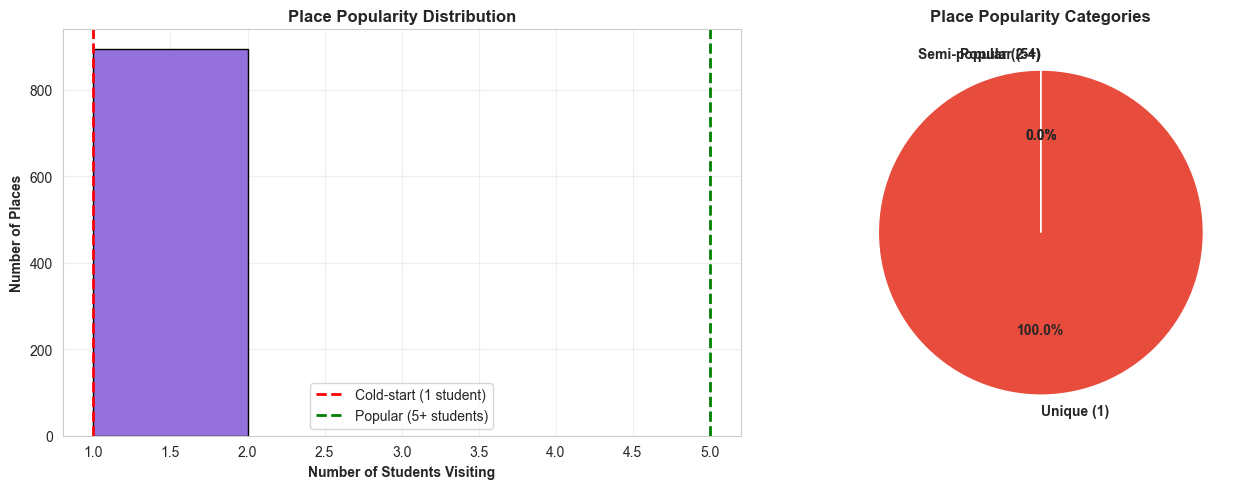


✓ Saved: results/figures/eda_visuals/place_popularity_coldstart.png


In [15]:
print("=" * 80)
print("PLACE POPULARITY & COLD-START ANALYSIS")
print("=" * 80)

# Count students per place
place_popularity = df.groupby('Image URL')['student_id'].nunique().sort_values(ascending=False)

print(f"\n📊 Place Popularity Statistics:")
print(place_popularity.describe())

# Cold-start analysis
unique_places = (place_popularity == 1).sum()
popular_places = (place_popularity >= 5).sum()

print(f"\n❄️ Cold-Start Metrics:")
print(f"  • Unique places (1 student): {unique_places} ({unique_places/len(place_popularity)*100:.1f}%)")
print(f"  • Popular places (5+ students): {popular_places} ({popular_places/len(place_popularity)*100:.1f}%)")
print(f"  • Semi-popular (2-4 students): {((place_popularity >= 2) & (place_popularity < 5)).sum()}")

# Top popular places
print(f"\n🏆 Top 10 Most Popular Places:")
for i, (url, count) in enumerate(place_popularity.head(10).items(), 1):
    place_row = df[df['Image URL'] == url].iloc[0]
    print(f"  {i}. {count} students - {place_row['Country_Standardized']} - {place_row['Activity_Type']}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Popularity distribution
ax = axes[0]
ax.hist(place_popularity, bins=range(1, min(place_popularity.max()+2, 21)), 
       edgecolor='black', color='mediumpurple')
ax.set_xlabel('Number of Students Visiting', fontweight='bold')
ax.set_ylabel('Number of Places', fontweight='bold')
ax.set_title('Place Popularity Distribution', fontweight='bold')
ax.axvline(x=1, color='red', linestyle='--', linewidth=2, label='Cold-start (1 student)')
ax.axvline(x=5, color='green', linestyle='--', linewidth=2, label='Popular (5+ students)')
ax.legend()
ax.grid(alpha=0.3)

# Pie chart
ax = axes[1]
categories = ['Unique (1)', 'Semi-popular (2-4)', 'Popular (5+)']
counts = [
    unique_places,
    ((place_popularity >= 2) & (place_popularity < 5)).sum(),
    popular_places
]
colors_pie = ['#e74c3c', '#f39c12', '#2ecc71']
ax.pie(counts, labels=categories, autopct='%1.1f%%', colors=colors_pie, startangle=90,
      textprops={'fontweight': 'bold'})
ax.set_title('Place Popularity Categories', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('../results/figures/eda_visuals/place_popularity_coldstart.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: results/figures/eda_visuals/place_popularity_coldstart.png")

## 8. Save Results

In [16]:
# Save student features with clusters
student_df.to_csv('../results/metrics/student_features_with_archetypes.csv', index=False)
print("✓ Saved: results/metrics/student_features_with_archetypes.csv")

# Save archetype definitions
with open('../results/metrics/traveler_archetypes.json', 'w') as f:
    json.dump(archetypes, f, indent=2)
print("✓ Saved: results/metrics/traveler_archetypes.json")

# Save summary statistics
summary = {
    'total_students': len(student_df),
    'n_clusters': optimal_k,
    'archetypes': archetypes,
    'diversity_stats': {
        'avg_activity_diversity': float(student_df['n_activities'].mean()),
        'avg_country_diversity': float(student_df['n_countries'].mean()),
        'avg_activity_entropy': float(student_df['activity_entropy'].mean())
    },
    'place_popularity': {
        'unique_places': int(unique_places),
        'semi_popular_places': int(((place_popularity >= 2) & (place_popularity < 5)).sum()),
        'popular_places': int(popular_places)
    }
}

with open('../results/metrics/student_analysis_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print("✓ Saved: results/metrics/student_analysis_summary.json")

✓ Saved: results/metrics/student_features_with_archetypes.csv
✓ Saved: results/metrics/traveler_archetypes.json
✓ Saved: results/metrics/student_analysis_summary.json


## 9. Task Completion Summary

In [17]:
print("=" * 80)
print("TASK 1.5c COMPLETE: STUDENT PREFERENCE ANALYSIS")
print("=" * 80)

print("\n✓ Checklist Completed:")
print("  ✓ Cluster students using preference features")
print("  ✓ Dimensionality reduction (t-SNE and PCA)")
print("  ✓ Identify traveler archetypes")
print("  ✓ Preference diversity (entropy per student)")
print("  ✓ Place popularity and cold-start analysis")

print("\n✓ Deliverables:")
print("  ✓ notebooks/eda_student_analysis.ipynb")
print("  ✓ results/figures/eda_visuals/preference_diversity.png")
print("  ✓ results/figures/eda_visuals/clustering_analysis.png")
print("  ✓ results/figures/eda_visuals/student_clustering_visualization.png")
print("  ✓ results/figures/eda_visuals/traveler_archetypes.png")
print("  ✓ results/figures/eda_visuals/place_popularity_coldstart.png")
print("  ✓ results/metrics/student_features_with_archetypes.csv")
print("  ✓ results/metrics/traveler_archetypes.json")
print("  ✓ results/metrics/student_analysis_summary.json")

print("\n" + "=" * 80)

TASK 1.5c COMPLETE: STUDENT PREFERENCE ANALYSIS

✓ Checklist Completed:
  ✓ Cluster students using preference features
  ✓ Dimensionality reduction (t-SNE and PCA)
  ✓ Identify traveler archetypes
  ✓ Preference diversity (entropy per student)
  ✓ Place popularity and cold-start analysis

✓ Deliverables:
  ✓ notebooks/eda_student_analysis.ipynb
  ✓ results/figures/eda_visuals/preference_diversity.png
  ✓ results/figures/eda_visuals/clustering_analysis.png
  ✓ results/figures/eda_visuals/student_clustering_visualization.png
  ✓ results/figures/eda_visuals/traveler_archetypes.png
  ✓ results/figures/eda_visuals/place_popularity_coldstart.png
  ✓ results/metrics/student_features_with_archetypes.csv
  ✓ results/metrics/traveler_archetypes.json
  ✓ results/metrics/student_analysis_summary.json

